In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

### Название столбца   ||   Описание
- **realSum**: Общая стоимость объявления на Airbnb. (*Числовое значение*)
- **room_type**: Тип предлагаемой комнаты (например, отдельная, общая и т. д.). (*Категориальное значение*)
- **room_shared**: Является ли комната общей. (*Булево значение*)
- **room_private**: Является ли комната частной или нет. (*Булево значение*)
- **person_capacity**: Максимальное количество человек, которые могут разместиться в комнате. (*Числовое значение*)
- **host_is_superhost**: Является ли хозяин суперхозяином или нет. (*Булево значение*)
- **multi**: Предлагается ли в объявлении несколько комнат или нет. (*Булево значение*)
- **biz**: Указывает, предназначено ли объявление для деловых целей. (*Булево значение*)
- **cleanliness_rating**: Рейтинг чистоты объявления. (*Числовое значение*)
- **guest_satisfaction_overall**: Общий рейтинг удовлетворенности гостей объявлением. (*Числовое значение*)
- **bedrooms**: Количество спален в объявлении. (*Числовое значение*)
- **dist**: Расстояние от центра города. (*Числовое значение*)
- **metro_dist**: Расстояние до ближайшей станции метро. (*Числовое значение*)
- **attr_index**: Индекс привлекательности места, указанного в списке (*Числовое значение*)
- **attr_index_norm**: Нормализованный индекс привлекательности (0–100) (*Числовое значение*)
- **rest_index**: Индекс ресторанов места, указанного в списке (*Числовое значение*)
- **rest_index_norm**: Нормализованный индекс ресторанов (0–100) (*Числовое значение*)
- **lng**: Долгота объекта. (*Числовое значение*)
- **lat**: Широта объекта. (*Числовое значение*)

#### **Цель:**

Моя главная цель **создать универсальный ETL** для данных используя объект **class**. Этот ETL будет DataPreprocessing class.

* __init__: np.array
* get(): выведет данные по одному
* add_data(): будет добавлять все в большой DataFrame
* save_data(): Сохранит данные в csv
* etl(): это основной метод
* get_features_info(): Даст информацию по фичам
* null_features(): Дает соотношение пустых данных по колонкам
* corelate_features_target(): Дает корреляцию между фичами и целевой переменной
* visualization_features(): Дает визуализацию фичей
* drop_features_nulls_more(): Удаляет часть колонок у которых соотношение пустых больше x
* drop_specified_features(): Удаляет список колонок которых я укажу
* (?) get_top_features(): взять top_n колонок, указать method по которому они были выбраны
* preprocessing_int_float_features(): Делает предобработку числовым данным (StandardScaler, MinMaxScaler) | Надо не забывать про природу данных а именно их распределение
* preprocessing_label_features(): Делает предобработку категориальным фичам (OneHotEncoder, LabelEncoder)
* drop_dublicates(): удаляет дубли
* add_specific_columns_by_data(): Добавляет специфичные по задаче колонки
* visualize_noise(): Визуализирует шумы
* drop_noise_columns(): Удаляет шумы в данных

In [4]:
df = pd.read_csv(r"..\test_data\amsterdam_weekdays.csv", index_col=0)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1103 entries, 0 to 1102
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   realSum                     1103 non-null   float64
 1   room_type                   1103 non-null   object 
 2   room_shared                 1103 non-null   bool   
 3   room_private                1103 non-null   bool   
 4   person_capacity             1103 non-null   float64
 5   host_is_superhost           1103 non-null   bool   
 6   multi                       1103 non-null   int64  
 7   biz                         1103 non-null   int64  
 8   cleanliness_rating          1103 non-null   float64
 9   guest_satisfaction_overall  1103 non-null   float64
 10  bedrooms                    1103 non-null   int64  
 11  dist                        1103 non-null   float64
 12  metro_dist                  1103 non-null   float64
 13  attr_index                  1103 non-n

In [5]:
type(df)

pandas.core.frame.DataFrame

In [6]:
type(df)

pandas.core.frame.DataFrame

In [7]:
np.array(df)

array([[194.03369812293488, 'Private room', False, ...,
        6.846472824200016, 4.90569, 52.41772],
       [344.2457760176224, 'Private room', False, ..., 58.34292774344904,
        4.90005, 52.37432],
       [264.1014224451058, 'Private room', False, ..., 6.646700254501156,
        4.97512, 52.36103],
       ...,
       [317.0623110632016, 'Private room', False, ..., 43.6169267144573,
        4.88897, 52.37798],
       [1812.8559042017205, 'Entire home/apt', False, ...,
        23.454022262581173, 4.90688, 52.35794],
       [258.0085768518736, 'Shared room', True, ..., 56.26722572511592,
        4.89295, 52.37575]], shape=(1103, 19), dtype=object)

In [8]:
df.isna().mean()

realSum                       0.0
room_type                     0.0
room_shared                   0.0
room_private                  0.0
person_capacity               0.0
host_is_superhost             0.0
multi                         0.0
biz                           0.0
cleanliness_rating            0.0
guest_satisfaction_overall    0.0
bedrooms                      0.0
dist                          0.0
metro_dist                    0.0
attr_index                    0.0
attr_index_norm               0.0
rest_index                    0.0
rest_index_norm               0.0
lng                           0.0
lat                           0.0
dtype: float64

In [43]:
class my_ETL:
    
    def __init__(self, rows: pd.DataFrame, null_threshold: float, drop_features: list, save_path: str) -> None:
        self.df = rows
        self.null_threshold = null_threshold
        self.drop_features = drop_features
        self.save_path = save_path
        
        self.rows_numpy_arr = np.array(rows)
        
    def get(self):
        
        for i in self.rows_numpy_arr:
            yield i
    
    def get_new_df(self):
        
        return self.df
        
    def change_numpy_arr(self, x: pd.DataFrame) -> np.array:
        # Конвертирует pd.DataFrame -> np.array
        # Этот метод будет полезен, когда мне нужно будет работать с данными по строчно
        
        self.rows_numpy_arr = np.array(x)
        
        return self.rows_numpy_arr
            
    def get_features_type(self) -> dict:
        # Возвращяет {'type': [count, [features]]}
        
        types = ['int', 'float', 'object', 'bool']
        types_count_dict = dict()
        
        for t in types:
            types_count_dict[t] = [len(self.df.select_dtypes(include=t).columns), list(self.df.select_dtypes(include=t).columns)]
            
        print("Return Features Types -------------------- ✅")
        
        return types_count_dict

    def drop_dublicates(self) -> None:
        # Удаляет дубликаты
    
        count_duplicates = len(self.df[self.df.duplicated()])
        print(f"Количество дубликатов: {count_duplicates}")
        
        self.df = self.df.drop_duplicates()
        
        print("Drop Duplicates -------------------- ✅")
        
        
    def change_features_types(self, change_features_dict: dict, save_changes = False) -> pd.DataFrame:
        # Я вручную указываю для каких колонок поменять тип
        
        df_new = self.df.copy()
        
        for features, new_type in change_features_dict.items():
            df_new[features] = df_new[features].astype(new_type)
        
        if save_changes == True:
            self.df = df_new
            
        print("Change Features Types -------------------- ✅")
        
        return df_new
        
    
    def drop_specified_features(self) -> None:
        # Удаляет колонки которых я посчитал не нужными
        
        self.df = self.df.drop(columns=self.drop_features)
        
        print(f"Drop Specified Features | {self.drop_features} -------------------- ✅")
    
    
    def null_features(self) -> None:
        # Дает информацию про пустотам в данных и удаляет колонки, которых соотношение пустот больше лимита
        
        nulls_features = self.df.isna().mean()
        
        print(f"Ratio of nulls in columns: \n{nulls_features}")
        
        drop_null_cols = nulls_features[nulls_features > self.null_threshold].index.to_list()
        self.df = self.df.drop(columns=drop_null_cols)
        
        print(f"Droped columns with nulls | {drop_null_cols}")
        
        print("Get And Drop Null Features -------------------- ✅")
    
    
    def get_log_scaler(self, x):
        # Используется для данных имеющий хвост
        return np.log1p(x)

    
    def get_absolute_max_scaler(self, x):
        # Делит данные на обсолютное максимальное значение
        max_abs = np.max(np.abs(x))
        
        return x/max_abs
    
    
    def preprocessing_int_float_features(self, num_features_methods_dict: dict) -> pd.DataFrame:
        # Предобработка числовых данных
        
        for method, features in num_features_methods_dict.items():
            if method == 'MinMaxScaler':
                ss = MinMaxScaler()
                self.df[features] = ss.fit_transform(
                    self.df[features]
                )
            if method == 'LogScaler':
                for f in features:
                    self.df[f] = self.get_log_scaler(self.df[f])
            if method == 'AbsoluteMaxScaler':
                for f in features:
                    self.df[f] = self.get_absolute_max_scaler(self.df[f])
        
        print("Preprocessing Int Float Features -------------------- ✅")
        
        return self.df
    
    
    def preprocessing_cat_features(self, cat_features_methods_dict: dict) -> pd.DataFrame:
        # Предобработка категориальные данных
        
        for method, features in cat_features_methods_dict.items():
            if method == 'OneHotEncoder':
                ohe = OneHotEncoder(handle_unknown='ignore',
                                    sparse_output=False)
                
                encoded = ohe.fit_transform(
                    self.df[features]
                )
                
                encoded_df = pd.DataFrame(encoded, 
                                          columns=ohe.get_feature_names_out(features), 
                                          index=self.df.index
                                        )

                self.df = pd.concat(
                    [self.df.drop(columns=features), encoded_df],
                    axis=1
                )
            if method == 'LabelEncoder':
                # Пока не добавлял
                print('...')
        
        print("Preprocessing Categorical Features -------------------- ✅")      
            
        return self.df
    
    
    def change_columns_name(self) -> None:
        # Просто заменяет [' ', '/'] на '_'
        
        self.df.columns = self.df.columns.str.replace(' ', '_')
        self.df.columns = self.df.columns.str.replace('/', '_')
        
        print("Change Columns Name (' ', '/') -------------------- ✅")



drop_features = ['lng', 'lat', 'attr_index_norm', 'rest_index_norm', 'room_shared', 'room_private']
save_path = 'here'
num_limit = 0.5

me = my_ETL(df, num_limit, drop_features, save_path)

# Pipline
me.drop_specified_features()
me.drop_dublicates()

f_types = me.get_features_type()
for i, j in f_types.items():
    print(i, j)

chng_types = {
    'person_capacity': 'int',
    'multi': 'bool',
    'biz': 'bool'
}
df_new = me.change_features_types(change_features_dict=chng_types, save_changes=True)

f_types = me.get_features_type()
for i, j in f_types.items():
    print(i, j)
        
me.null_features()

num_features_methods_dict = {
    'StandardScaler': ['dist', 'metro_dist', 'attr_index', 'rest_index'],
    'LogScaler': ['realSum'],
    'AbsoluteMaxScaler': ['cleanliness_rating', 'guest_satisfaction_overall']
}

df_new = me.preprocessing_int_float_features(num_features_methods_dict)

cat_features_methods_dict = {
    'OneHotEncoder': ['room_type']
}

df_new = me.preprocessing_cat_features(cat_features_methods_dict)
me.change_columns_name()

df_new = me.get_new_df()

chng_types = {
    'room_type_Entire_home_apt': 'bool',
    'room_type_Private_room': 'bool',
    'room_type_Shared_room': 'bool'
}
df_new = me.change_features_types(change_features_dict=chng_types, save_changes=True)
 

Drop Specified Features | ['lng', 'lat', 'attr_index_norm', 'rest_index_norm', 'room_shared', 'room_private'] -------------------- ✅
Количество дубликатов: 0
Drop Duplicates -------------------- ✅
Return Features Types -------------------- ✅
int [3, ['multi', 'biz', 'bedrooms']]
float [8, ['realSum', 'person_capacity', 'cleanliness_rating', 'guest_satisfaction_overall', 'dist', 'metro_dist', 'attr_index', 'rest_index']]
object [1, ['room_type']]
bool [1, ['host_is_superhost']]
Change Features Types -------------------- ✅
Return Features Types -------------------- ✅
int [2, ['person_capacity', 'bedrooms']]
float [7, ['realSum', 'cleanliness_rating', 'guest_satisfaction_overall', 'dist', 'metro_dist', 'attr_index', 'rest_index']]
object [1, ['room_type']]
bool [3, ['host_is_superhost', 'multi', 'biz']]
Ratio of nulls in columns: 
realSum                       0.0
room_type                     0.0
person_capacity               0.0
host_is_superhost             0.0
multi                   

<Axes: >

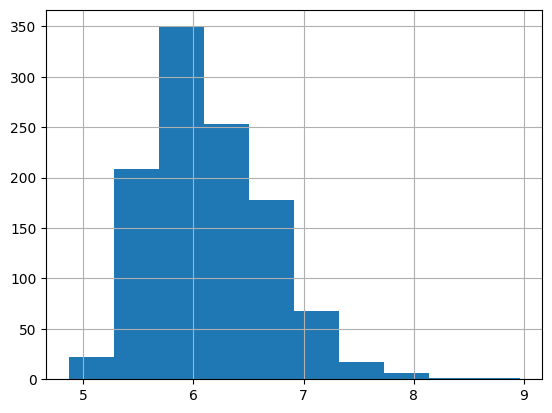

In [35]:
df_new['realSum'].hist()

In [30]:
df_new['person_capacity'].unique()

array([2, 4, 3, 6, 5])

In [ ]:
df_new['room_type_Entire home/apt']

,realSum,person_capacity,host_is_superhost,multi,biz,cleanliness_rating,guest_satisfaction_overall,bedrooms,dist,metro_dist,attr_index,rest_index,room_type_Entire home/apt,room_type_Private room,room_type_Shared room
0,5.273172,2,False,True,False,1.0,0.93,1,5.022964,2.539380,78.690379,98.253896,0.0,1.0,0.0
1,5.844257,4,False,False,False,0.8,0.85,1,0.488389,0.239404,631.176378,837.280757,0.0,1.0,0.0
2,5.580112,2,False,False,True,0.9,0.87,1,5.748312,3.651621,75.275877,95.386955,0.0,1.0,0.0
3,6.074264,4,False,False,True,0.9,0.90,2,0.384862,0.439876,493.272534,875.033098,0.0,1.0,0.0
4,6.187346,2,True,False,False,1.0,0.98,1,0.544738,0.318693,552.830324,815.305740,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1098,7.818879,2,False,False,False,1.0,1.00,1,2.375833,1.436054,181.198355,225.304203,1.0,0.0,0.0
1099,5.458040,2,False,True,False,1.0,0.90,1,4.719736,0.322263,108.024880,134.775277,0.0,1.0,0.0
1100,5.762247,2,False,True,False,1.0,0.92,1,0.598355,0.751993,440.476515,625.947562,0.0,1.0,0.0
1101,7.503210,4,False,False,False,0.8,0.84,5,1.943020,0.388532,257.948105,336.589237,1.0,0.0,0.0


In [46]:
df_new.select_dtypes(include=['int', 'float']).corr()

,realSum,person_capacity,cleanliness_rating,guest_satisfaction_overall,bedrooms,dist,metro_dist,attr_index,rest_index
realSum,1.000000,0.618366,0.019394,0.159394,0.539822,-0.391726,-0.225194,0.339621,0.312379
person_capacity,0.618366,1.000000,-0.065680,0.035399,0.660776,-0.046410,-0.003328,0.044485,0.008940
cleanliness_rating,0.019394,-0.065680,1.000000,0.648809,-0.015326,-0.021712,0.019532,-0.006147,0.010937
guest_satisfaction_overall,0.159394,0.035399,0.648809,1.000000,0.104254,-0.059805,0.050810,0.006316,-0.004934
bedrooms,0.539822,0.660776,-0.015326,0.104254,1.000000,0.021662,0.015170,-0.021489,-0.071591
dist,-0.391726,-0.046410,-0.021712,-0.059805,0.021662,1.000000,0.412042,-0.705351,-0.751632
metro_dist,-0.225194,-0.003328,0.019532,0.050810,0.015170,0.412042,1.000000,-0.467947,-0.489143
attr_index,0.339621,0.044485,-0.006147,0.006316,-0.021489,-0.705351,-0.467947,1.000000,0.861256
rest_index,0.312379,0.008940,0.010937,-0.004934,-0.071591,-0.751632,-0.489143,0.861256,1.000000
